In [14]:
"""
COSC2820 — Individual Task 1, Part 1.3
Complete analysis: training, evaluation, and figure generation.

Requires in the same folder:
  car_sales_data.csv   (50,000 rows — Manufacturer/Model/Engine size/...)
  car_prices.csv       (558,837 rows — from car_prices_csv.zip)
"""

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from xgboost import XGBRegressor

plt.rcParams.update({'font.size': 8, 'figure.dpi': 200})
le = LabelEncoder()

In [15]:
# DATASET A Random Forest
df_a = pd.read_csv('car_sales_data.csv')

df_a['Manufacturer_enc'] = le.fit_transform(df_a['Manufacturer'])
df_a['Model_enc']        = le.fit_transform(df_a['Model'])
df_a['Fuel_enc']         = le.fit_transform(df_a['Fuel type'])

X_a = df_a[['Manufacturer_enc', 'Model_enc', 'Engine size','Fuel_enc', 'Year of manufacture', 'Mileage']]
y_a = df_a['Price']

X_tr, X_te, y_tr, y_te = train_test_split(X_a, y_a, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_tr, y_tr)

p_a = rf.predict(X_te)

#Compute metrics from those predictions
mae_a  = mean_absolute_error(y_te, p_a)
rmse_a = np.sqrt(mean_squared_error(y_te, p_a))
r2_a   = r2_score(y_te, p_a)
mape_a = np.mean(np.abs((y_te - p_a) / y_te)) * 100
cv_a   = cross_val_score(rf, X_a, y_a,cv=KFold(n_splits=5, shuffle=True, random_state=42),scoring='r2')

print("Dataset A — Random Forest")
print(f"  MAE   = {mae_a:,.2f}")
print(f"  RMSE  = {rmse_a:,.2f}")
print(f"  R2    = {r2_a:.4f}")
print(f"  MAPE  = {mape_a:.2f}%")
print(f"  CV R2 = {cv_a.mean():.4f} +/- {cv_a.std():.4f}")

fi_a = pd.Series(rf.feature_importances_,index=['Manuf.', 'Model', 'Engine', 'Fuel', 'Year', 'Mileage']).sort_values()

Dataset A — Random Forest
  MAE   = 332.43
  RMSE  = 689.75
  R2    = 0.9982
  MAPE  = 3.72%
  CV R2 = 0.9982 +/- 0.0003


In [17]:
# DATASET B XGBoost
df_b = pd.read_csv('car_prices.csv').sample(n=50000, random_state=42)
df_b = df_b.dropna(subset=['sellingprice', 'odometer', 'condition', 'year'])

df_b['body']         = df_b['body'].str.lower().str.strip()
df_b['transmission'] = df_b['transmission'].str.lower().str.strip()
df_b['transmission'] = df_b['transmission'].apply(lambda x: x if x in ['automatic', 'manual'] else 'automatic')

for col in ['make', 'body', 'transmission', 'state', 'color']:
    df_b[col] = df_b[col].fillna('unknown')
    df_b[col + '_enc'] = le.fit_transform(df_b[col].astype(str))

X_b = df_b[['year','make_enc','body_enc','transmission_enc','condition','odometer','color_enc','state_enc']]
y_b = df_b['sellingprice']

X_tr2, X_te2, y_tr2, y_te2 = train_test_split(X_b, y_b, test_size=0.2, random_state=42)

xgb = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=6,random_state=42, n_jobs=-1, verbosity=0)
xgb.fit(X_tr2, y_tr2)

p_b = xgb.predict(X_te2)

mae_b  = mean_absolute_error(y_te2, p_b)
rmse_b = np.sqrt(mean_squared_error(y_te2, p_b))
r2_b   = r2_score(y_te2, p_b)
mape_b = np.mean(np.abs((y_te2 - p_b) / y_te2)) * 100
cv_b   = cross_val_score(xgb, X_b, y_b, cv=3, scoring='r2')

print("\nDataset B — XGBoost")
print(f"  MAE   = {mae_b:,.2f}")
print(f"  RMSE  = {rmse_b:,.2f}")
print(f"  R2    = {r2_b:.4f}")
print(f"  MAPE  = {mape_b:.2f}%")
print(f"  CV R2 = {cv_b.mean():.4f} +/- {cv_b.std():.4f}")

fi_b = pd.Series(xgb.feature_importances_,index=['Year', 'Make', 'Body', 'Trans.', 'Cond.','Odo.', 'Color', 'State']).sort_values()


Dataset B — XGBoost
  MAE   = 2,560.17
  RMSE  = 4,163.28
  R2    = 0.8073
  MAPE  = 27.92%
  CV R2 = 0.8011 +/- 0.0050


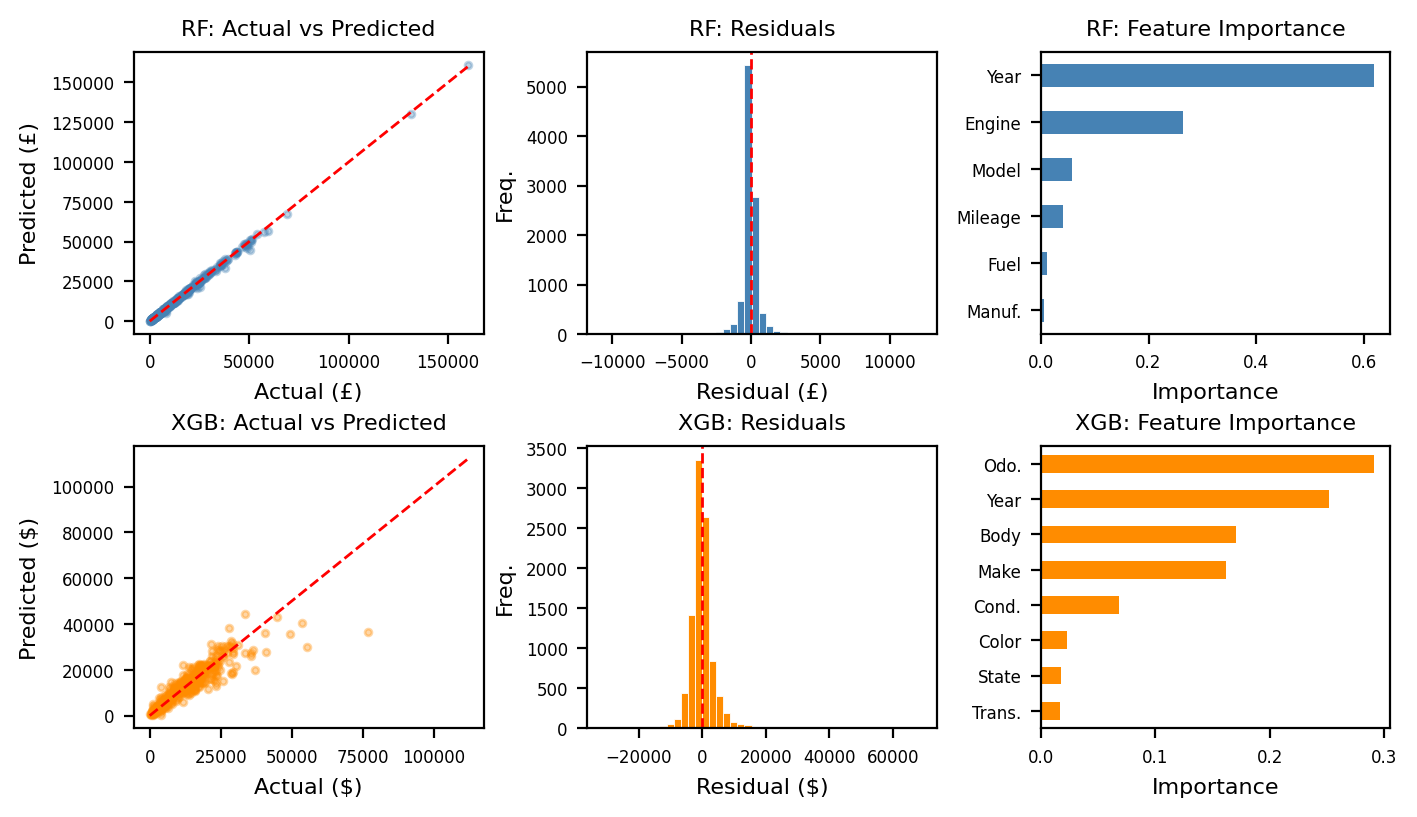


Saved fig1_models.png


In [19]:
fig, ax = plt.subplots(2, 3, figsize=(7.0, 4.0))
# Random Forest
i1 = np.random.choice(len(y_te), 400, replace=False)
ax[0, 0].scatter(y_te.values[i1], p_a[i1], alpha=.35, color='steelblue', s=6)
ax[0, 0].plot([0, y_te.max()], [0, y_te.max()], 'r--', lw=1)
ax[0, 0].set_xlabel('Actual (£)')
ax[0, 0].set_ylabel('Predicted (£)')
ax[0, 0].set_title('RF: Actual vs Predicted', fontsize=8)

ax[0, 1].hist(y_te.values - p_a, bins=45, color='steelblue',edgecolor='white', lw=.3)
ax[0, 1].axvline(0, color='red', ls='--', lw=1)
ax[0, 1].set_xlabel('Residual (£)')
ax[0, 1].set_ylabel('Freq.')
ax[0, 1].set_title('RF: Residuals', fontsize=8)

fi_a.plot(kind='barh', ax=ax[0, 2], color='steelblue')
ax[0, 2].set_xlabel('Importance')
ax[0, 2].set_title('RF: Feature Importance', fontsize=8)


# XGBoost
i2 = np.random.choice(len(y_te2), 400, replace=False)
ax[1, 0].scatter(y_te2.values[i2], p_b[i2], alpha=.35, color='darkorange', s=6)
ax[1, 0].plot([0, y_te2.max()], [0, y_te2.max()], 'r--', lw=1)
ax[1, 0].set_xlabel('Actual ($)')
ax[1, 0].set_ylabel('Predicted ($)')
ax[1, 0].set_title('XGB: Actual vs Predicted', fontsize=8)

ax[1, 1].hist(y_te2.values - p_b, bins=45, color='darkorange',edgecolor='white', lw=.3)
ax[1, 1].axvline(0, color='red', ls='--', lw=1)
ax[1, 1].set_xlabel('Residual ($)')
ax[1, 1].set_ylabel('Freq.')
ax[1, 1].set_title('XGB: Residuals', fontsize=8)

fi_b.plot(kind='barh', ax=ax[1, 2], color='darkorange')
ax[1, 2].set_xlabel('Importance')
ax[1, 2].set_title('XGB: Feature Importance', fontsize=8)


for a in ax.flat:
    a.tick_params(labelsize=6)

plt.tight_layout(pad=0.5)
plt.savefig('fig1_models.png', bbox_inches='tight', dpi=200)
plt.show()

print("\nSaved fig1_models.png")